# 06. Итоговый pipeline и тестирование

оформленный pipeline решения задачи прогнозирования временного ряда и провести базовое тестирование.

Pipeline находится в `src/ts_pipeline.py`.

In [1]:
from pathlib import Path
import sys
import time

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebook':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.ts_pipeline import (
    load_series,
    infer_frequency,
    infer_season_length,
    split_series,
    run_lightweight_pipeline,
)

REPORT_DIR = PROJECT_ROOT / 'reports'
FIG_DIR = REPORT_DIR / 'figures'
REPORT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
TARGET_PATH = PROJECT_ROOT / 'data' / 'raw' / 'international-airline-passengers.csv'

start = time.perf_counter()
series = load_series(TARGET_PATH, name='airline_passengers')
load_seconds = time.perf_counter() - start

print('Загружено наблюдений:', len(series))
print('Частота:', infer_frequency(series))
print('Сезонный период:', infer_season_length(series))
print('Время загрузки:', round(load_seconds, 6), 'сек.')

Загружено наблюдений: 144
Частота: MS
Сезонный период: 12
Время загрузки: 0.015532 сек.


/home/osboxes/Desktop/project_neto_time_completion/src/ts_pipeline.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed.loc[regular] = pd.to_datetime(text.loc[regular], errors="coerce")


In [3]:
train, test = split_series(series, test_size=12)

assert train.index.max() < test.index.min(), 'Ошибка: train и test пересекаются по времени'
assert len(train) + len(test) == len(series), 'Ошибка: нарушено разбиение ряда'
assert len(test) == 12, 'Ошибка: тестовый горизонт должен быть равен 12'

print('Pipeline test passed')
print('train:', train.index.min(), train.index.max(), len(train))
print('test:', test.index.min(), test.index.max(), len(test))

Pipeline test passed
train: 1949-01-01 00:00:00 1959-12-01 00:00:00 132
test: 1960-01-01 00:00:00 1960-12-01 00:00:00 12


Разбиение выполнено: обучающая выборка содержит данные с января 1949 по декабрь 1959, тестовая выборка - с января 1960 по декабрь 1960. Проверки `assert` подтверждают, что train и test не пересекаются по времени, общая длина ряда сохранена, а горизонт тестирования равен 12 месяцам.

Важный момент: модель должна прогнозировать будущее по прошлому, без случайного перемешивания наблюдений и без утечки информации из тестового периода.

In [4]:
result = run_lightweight_pipeline(series, test_size=12)

result.metrics.to_csv(REPORT_DIR / 'final_pipeline_results.csv', index=False)
result.performance.to_csv(REPORT_DIR / 'pipeline_performance.csv', index=False)

display(result.metrics)
display(result.performance)

,MAE,RMSE,MAPE,sMAPE,model
1,47.833333,50.708316,9.987533,10.571808,SeasonalNaive
2,66.307888,92.666363,12.417957,13.814045,Drift
0,76.000000,102.976535,14.251338,16.120845,Naive


,model,seconds
0,Naive,0.000029
1,SeasonalNaive,0.000067
2,Drift,0.000744


Pipeline успешно построил несколько простых baseline-моделей и рассчитал метрики качества. Лучший результат среди baseline-подходов показала модель `SeasonalNaive`: MAE = 47.83, RMSE = 50.71, MAPE = 9.99%.
Результат для данного ряда таков, потому что пассажиропоток имеет выраженную годовую сезонность. Обычная `Naive`-модель и `Drift` учитывают общую динамику слабее, поэтому ошибаются заметно сильнее. По времени выполнения все baseline-модели работают практически мгновенно, поэтому такой pipeline удобно использовать как быстрый контрольный уровень качества.

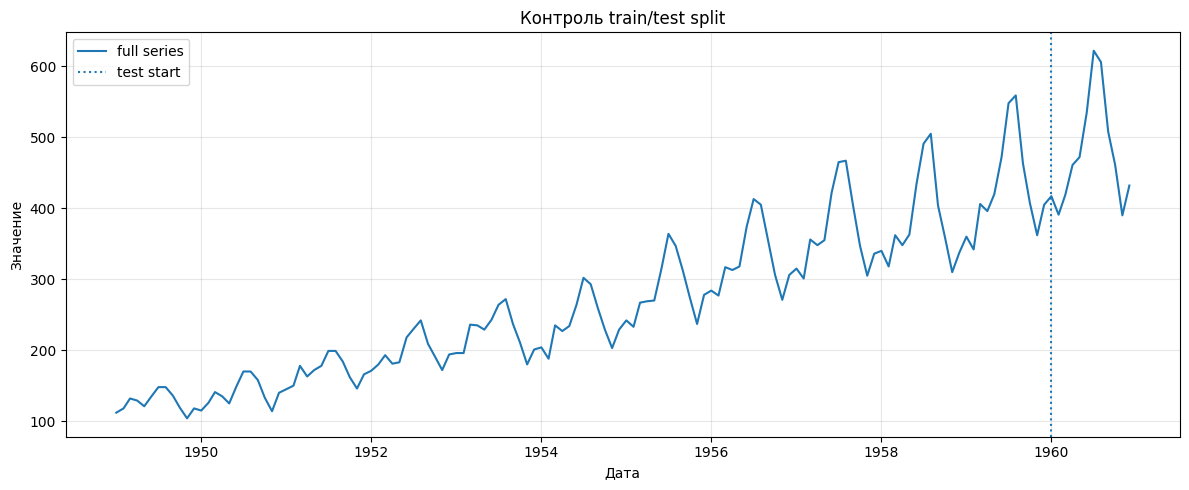

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(series.index, series.values, label='full series')
plt.axvline(test.index.min(), linestyle=':', label='test start')
plt.title('Контроль train/test split')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'final_pipeline_split.png', dpi=150)
plt.show()

График подтверждает корректность временного разбиения: тестовый период расположен строго в конце ряда и отделен вертикальной линией. Видно, что к 1960 году уровень пассажиропотока существенно выше, чем в начале наблюдений, а амплитуда сезонных колебаний со временем растет.

Это означает, что задача прогноза не сводится к простому повторению прошлого значения. Модели нужно учитывать одновременно тренд и сезонность. Поэтому `SeasonalNaive` работает лучше обычной `Naive`, но более сложные модели из предыдущих ноутбуков могут давать более точный прогноз.

## Итоговый вывод

Финальный lightweight pipeline корректно выполняет полный базовый контур решения задачи прогнозирования временного ряда: загрузку данных, определение частоты и сезонности, временное разбиение, построение baseline-прогнозов, расчет метрик, замер времени выполнения и сохранение результатов.

На тестовом горизонте 12 месяцев лучшей baseline-моделью стала `SeasonalNaive`:
- MAE = 47.83;
- RMSE = 50.71;
- MAPE = 9.99%;
- sMAPE = 10.57%.

Это подтверждает ключевую особенность ряда авиапассажиров: годовая сезонность является критически важной. Модель, которая просто повторяет значение прошлого сезона, оказывается заметно лучше обычной `Naive` и `Drift`.(`Drift` и `Naive`: RMSE = 92.67 и 102.98.)

Pipeline подтверждает базовую гипотезу проекта: для ряда авиапассажиров сезонность критична. При этом baseline pipeline не является финальным лучшим решением по качеству. Его задача - дать воспроизводимый минимальный контур и контрольный уровень ошибки. Более сильные результаты были получены в предыдущих ноутбуках с моделями статистического, ML- и DL-подходов. 
По ранее рассчитанным метрикам лучшие значения RMSE показали: `LSTM` - 18.01, `LinearRegression` - 19.36, `AutoARIMA` - 23.92.

Итог: `src/ts_pipeline.py` можно использовать как надежный базовый pipeline проекта. Он подтверждает корректность подготовки данных и дает понятный benchmark, с которым можно сравнивать более сложные модели. Для production-варианта лучше дополнительно расширить pipeline: добавить выбор лучшей модели по метрикам, сохранение обученной модели, конфигурационный файл и автоматическую генерацию итогового отчета.